<a href="https://colab.research.google.com/github/Khalidzo/hiding-information-in-explanations/blob/main/notebooks/CNN_HiddenInformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Khalid - Notebook

## Step 1: HG Login + Model and Dataset Load

In [8]:
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

In [9]:
from huggingface_hub import login
import numpy as np


login(token=HF_TOKEN)

In [10]:
import torch
print(torch.__version__) # Better GPU Version ok? Just check first

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", torch.cuda.get_device_name(0))

else:
    print("Using CPU")

2.11.0+cpu
Using CPU


In [11]:
from datasets import load_dataset
import torchvision.models as models
import torchvision.transforms as T
import matplotlib.pyplot as plt

dataset = load_dataset("ILSVRC/imagenet-1k", split="train", streaming=True)
model = models.resnet18(pretrained=True)
model.eval()

README.md:   0%|          | 0.00/87.6k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 391MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [12]:
import json
import urllib.request

# download the official class index mapping [idx <-> class_name]
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
class_names = urllib.request.urlopen(url).read().decode("utf-8").splitlines()

## Step 2: Image Preprocessing before inference (Resize -> Crop -> Normalize)

In [13]:
# preprocessing to match pretrained ResNet18 expectations
"""
Imagenet Dataset Preprocessing is done by scaling each image to a 224 × 224 resolution and normalizing RGB channels with a mean of [0.485, 0.456, 0.406] and a standard
deviation of [0.229, 0.224, 0.225], as for the training set of ImageNet [26].

REF: https://arxiv.org/pdf/2305.16361
"""
preprocess = T.Compose([
    T.Resize(256),
    T.CenterCrop(224), # Crop from the center to get a 224x224 image (ImageNet img sizes)
    T.ToTensor(), # Convert from PIL Image to PyTorch Tensor
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


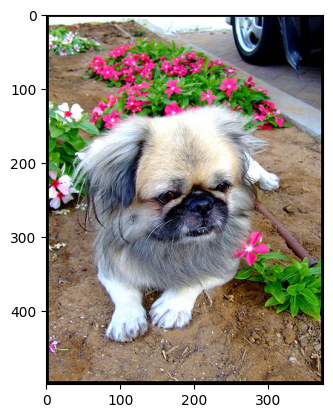

In [14]:
# grab a small snippet, e.g. 20 examples
examples = list(dataset.skip(20).take(20))

image = examples[17]["image"]

plt.imshow(image)

In [15]:
image_as_tensor = preprocess(image).unsqueeze(0)
image_as_tensor.requires_grad_(True)
image_as_tensor.shape

torch.Size([1, 3, 224, 224])

## Step 3: Inference

In [16]:
logits = model(image_as_tensor).squeeze(0)

probs = torch.softmax(logits, dim=0) # Apply softmax

top_k_predictions = torch.topk(probs, k=5)

top_k_predictions

torch.return_types.topk(
values=tensor([9.9460e-01, 4.1834e-03, 3.7188e-04, 3.6730e-04, 2.7654e-04],
       grad_fn=<TopkBackward0>),
indices=tensor([154, 155, 254, 152, 204]))

In [17]:
for prob, idx in zip(top_k_predictions.values, top_k_predictions.indices):
    print(f"Class {idx}/{class_names[idx]} with score: {prob:.3f}")

Class 154/Pekinese with score: 0.995
Class 155/Shih-Tzu with score: 0.004
Class 254/pug with score: 0.000
Class 152/Japanese spaniel with score: 0.000
Class 204/Lhasa with score: 0.000


In [18]:
top_idx = logits.argmax()

logits[top_idx].backward()

## Step 4: Saliency Map Generation aka Explaination Map

### Vanilla Gradients

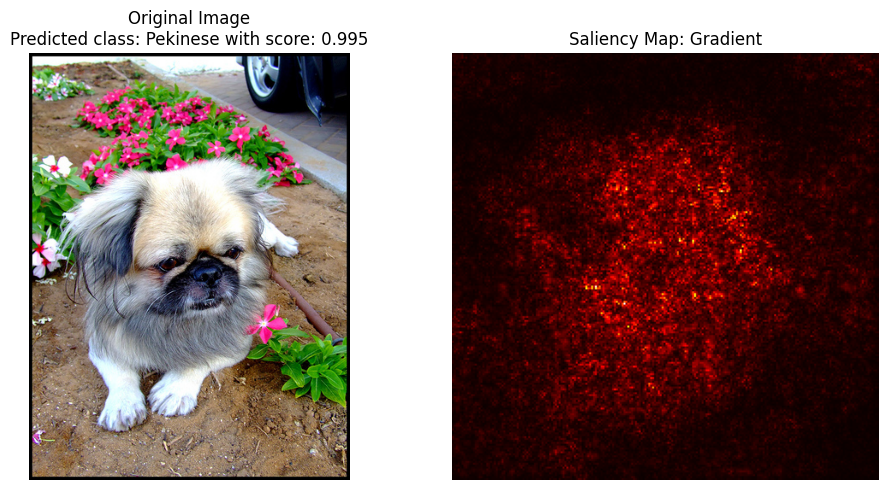

In [19]:
## 1. Vanilla gradients
gradients = image_as_tensor.grad
saliency_map = gradients.abs().max(dim=1).values.squeeze(0)
saliency_map = saliency_map / torch.sum(saliency_map)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Display the original image
ax[0].imshow(image)
ax[0].set_title(f"Original Image\nPredicted class: {class_names[top_idx]} with score: {probs[top_idx]:.3f}")
ax[0].axis("off")

# Display the gradients
ax[1].imshow(saliency_map.cpu(), cmap="hot")
ax[1].set_title("Saliency Map: Gradient")
ax[1].axis("off")

plt.tight_layout()
plt.show()

### Gradients x Input

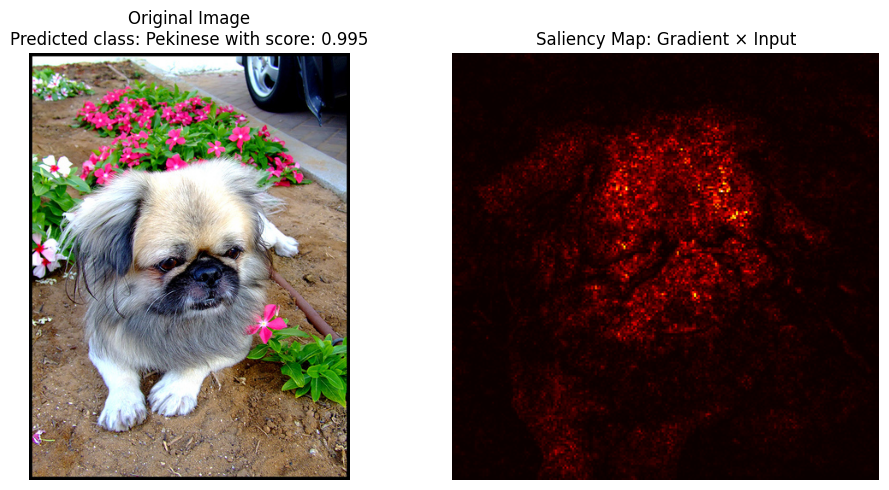

In [20]:
## 2. Gradient × Input
grad_times_input = gradients * image_as_tensor
saliency_map = (gradients * image_as_tensor).detach().abs().max(dim=1).values.squeeze(0).cpu()

saliency_map = saliency_map / torch.sum(saliency_map)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Display the original image
ax[0].imshow(image)
ax[0].set_title(f"Original Image\nPredicted class: {class_names[top_idx]} with score: {probs[top_idx]:.3f}")
ax[0].axis("off")

# Display the gradients
ax[1].imshow(saliency_map.cpu(), cmap="hot")
ax[1].set_title("Saliency Map: Gradient × Input")
ax[1].axis("off")

plt.tight_layout()
plt.show()

### IG: Integrated Gradients

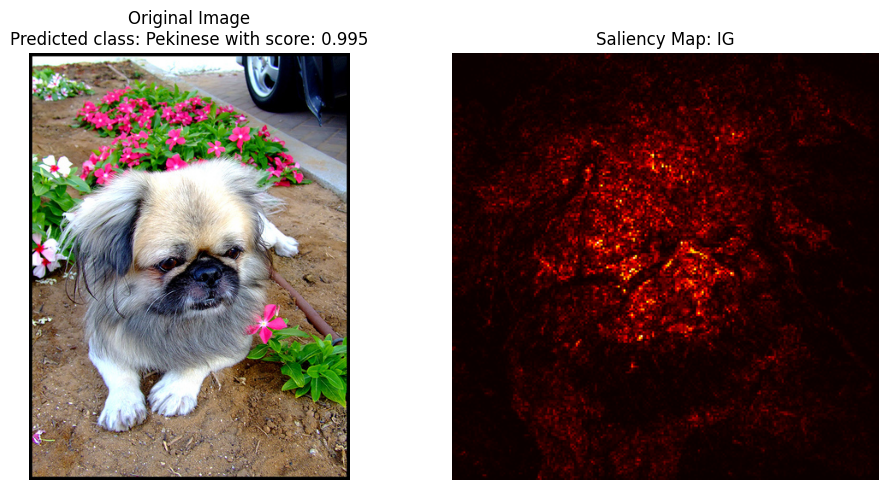

In [21]:
## 3. Integrated Gradients
N_SUMMANDS = 30

input_tensor = image_as_tensor.clone().detach()
prefactors = input_tensor.new_tensor([k / N_SUMMANDS for k in range(1, N_SUMMANDS + 1)])

parallel_model = torch.nn.DataParallel(model)
y = parallel_model(prefactors.view(N_SUMMANDS, 1, 1, 1) * image_as_tensor)

y = torch.nn.functional.softmax(y, 1)[:, int(top_idx)] # Get only score of the target label (aka just the highest score's index)

y = torch.sum(y / prefactors, dim=0)

grads = torch.autograd.grad(y, image_as_tensor)[0] # dy/dx
ig = (1 / N_SUMMANDS) * (grads * image_as_tensor).detach()
saliency_map = ig.abs().max(dim=1).values.squeeze(0).cpu()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Display the original image
ax[0].imshow(image)
ax[0].set_title(f"Original Image\nPredicted class: {class_names[top_idx]} with score: {probs[top_idx]:.3f}")
ax[0].axis("off")

# Display the gradients
ax[1].imshow(saliency_map, cmap="hot")
ax[1].set_title("Saliency Map: IG")
ax[1].axis("off")

plt.tight_layout()
plt.show()

### SmoothGrad

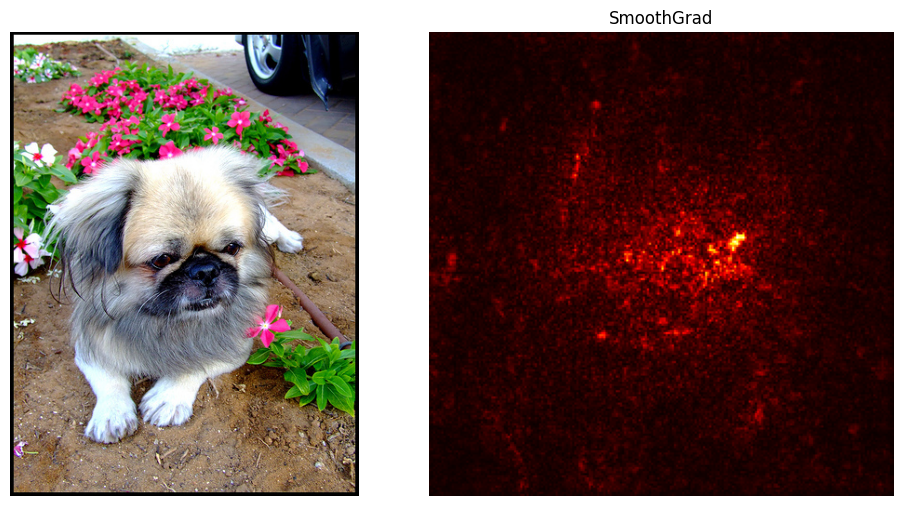

In [22]:
## 4. SmoothGrad
N_SAMPLES = 50
NOISE_LEVEL = 0.3   # σ as fraction of the input's value range

sigma = NOISE_LEVEL * (image_as_tensor.max() - image_as_tensor.min())
accumulated = torch.zeros_like(image_as_tensor)

for _ in range(N_SAMPLES):
    noisy = (image_as_tensor + sigma * torch.randn_like(image_as_tensor)).detach().requires_grad_(True)
    logits = model(noisy).squeeze(0)
    logits[top_idx].backward()
    accumulated += noisy.grad

smoothgrad = accumulated / N_SAMPLES
saliency_map = smoothgrad.abs().max(dim=1).values.squeeze(0).cpu()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image); ax[0].axis("off")
ax[1].imshow(saliency_map, cmap="hot")
ax[1].set_title("SmoothGrad")
ax[1].axis("off")
plt.tight_layout()
plt.show()

## Step 5: Generate Target Pattern

In [23]:
from PIL import Image, ImageDraw, ImageFont
import numpy as np

def generate_text_pattern(text, width, height, font_size=None,
                            bg_color=255, text_color=0, font_path=None):
    """
    Generates a grayscale image containing the given text, centered.

    Args:
        text: string to render (e.g. "HIDDEN")
        width, height: output image size in pixels
        font_size: font size in pixels. If None, auto-scales to fit the image.
        bg_color: background pixel value (0-255). Default 255 = white.
        text_color: text pixel value (0-255). Default 0 = black.
        font_path: path to a .ttf font file. If None, tries a common system font,
                    falling back to PIL's basic default font.

    Returns:
        PIL Image (mode 'L' = grayscale), size (width, height)
    """
    img = Image.new('L', (width, height), color=bg_color)
    draw = ImageDraw.Draw(img)

    # auto-scale font size to roughly fit the image if not specified
    if font_size is None:
        font_size = int(height * 0.3)

    # try to load a real scalable font; fall back gracefully
    font = None
    candidates = [font_path] if font_path else [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "DejaVuSans-Bold.ttf",
    ]
    for path in candidates:
        if path is None:
            continue
        try:
            font = ImageFont.truetype(path, font_size)
            break
        except (OSError, IOError):
            continue
    if font is None:
        font = ImageFont.load_default()  # small, fixed-size fallback

    # shrink font until text fits within the image (only works with truetype fonts)
    if hasattr(font, "path"):
        while font_size > 4:
            bbox = draw.textbbox((0, 0), text, font=font)
            text_w, text_h = bbox[2] - bbox[0], bbox[3] - bbox[1]
            if text_w <= width * 0.9 and text_h <= height * 0.9:
                break
            font_size -= 2
            font = ImageFont.truetype(font.path, font_size)

    # center the text
    bbox = draw.textbbox((0, 0), text, font=font)
    text_w, text_h = bbox[2] - bbox[0], bbox[3] - bbox[1]
    x = (width - text_w) / 2 - bbox[0]
    y = (height - text_h) / 2 - bbox[1]

    draw.text((x, y), text, fill=text_color, font=font)

    return img

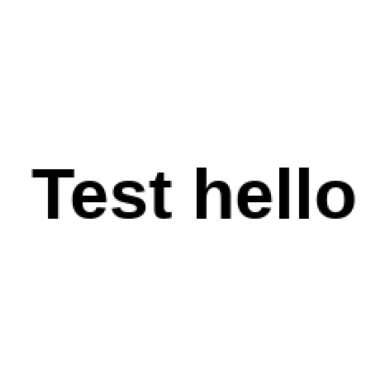

In [24]:
# Example usage
pattern = generate_text_pattern("Test hello", width=224, height=224)

import matplotlib.pyplot as plt
plt.imshow(pattern, cmap='gray')
plt.axis('off')
plt.show()

## Step 6: Prepare Saliency Map + Generated Pattern for the attack
> Normalization to [0, 1] etc..

In [25]:
# Transform saliency map into a normalize [0, 1] range form
p98_h = np.percentile(saliency_map, 98)
h_norm = np.clip(saliency_map, 0, p98_h) / p98_h

# Make h_norm sum up to one
h_norm = h_norm / h_norm.sum()

h_norm

tensor([[1.5274e-05, 1.5644e-05, 1.1022e-05,  ..., 3.8209e-06, 4.3118e-06,
         5.1912e-06],
        [1.1492e-05, 1.1625e-05, 2.0512e-05,  ..., 4.1146e-06, 5.1147e-06,
         3.4813e-06],
        [2.6550e-06, 1.7020e-05, 8.3870e-06,  ..., 6.2635e-06, 5.8940e-06,
         4.4232e-06],
        ...,
        [6.7903e-06, 1.2138e-05, 3.9419e-06,  ..., 1.0464e-05, 7.9231e-06,
         8.4917e-06],
        [6.0085e-06, 5.4660e-06, 3.2728e-06,  ..., 5.2769e-06, 4.6388e-06,
         4.0711e-06],
        [1.2554e-06, 1.5497e-06, 6.7207e-06,  ..., 7.1169e-06, 2.5806e-06,
         2.0104e-06]])

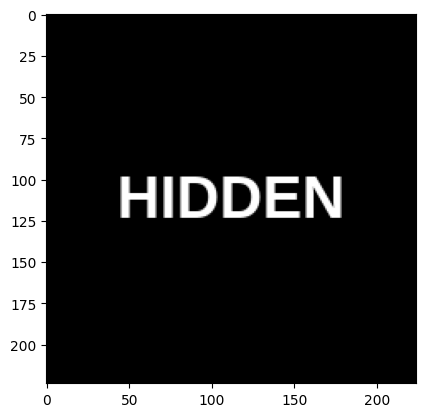

In [26]:
# Normalize also pattern map
# Create patter map (HIGH_VAL -> pattern, LOW_VAL -> background)
target_map = generate_text_pattern('HIDDEN', width=224, height=224, font_size=36, bg_color=0, text_color=255)

plt.imshow(target_map, cmap='gray')